In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

/Users/sophie/Seaglider/SeagliderData/DataManagement


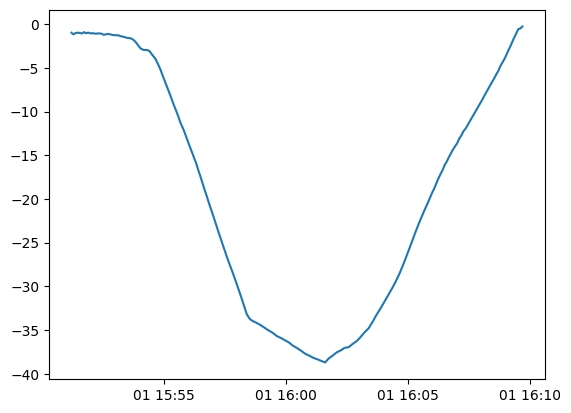

In [3]:
print(os.getcwd())
times_ds = xr.open_dataset('sg195_Elliot_Bay_BIG10__17May2024_timeseries.nc')
#display(times_ds)
times_ds.time.values[0]
times_ds['time'][0].values #same thing

time = times_ds.time.values
depth = times_ds.depth.values
plt.plot(time, -depth)

In [4]:
display(times_ds)

<xarray.Dataset> Size: 27kB
Dimensions:                                   (gps_info: 3, sg_data_point: 145,
                                               trajectory: 1, dive: 1)
Coordinates:
    ctd_time                                  (sg_data_point) datetime64[ns] 1kB ...
    ctd_depth                                 (sg_data_point) float32 580B ...
    latitude                                  (sg_data_point) float32 580B ...
    longitude                                 (sg_data_point) float32 580B ...
  * trajectory                                (trajectory) int32 4B 1
Dimensions without coordinates: gps_info, sg_data_point, dive
Data variables: (12/66)
    gps_info_dive_number                      (gps_info) int32 12B ...
    sg_data_point_dive_number                 (sg_data_point) int32 580B ...
    log_gps_time                              (gps_info) datetime64[ns] 24B ...
    time                                      (sg_data_point) datetime64[ns] 1kB ...
    pressure                                  (sg_data_point) float32 580B ...
    depth                                     (sg_data_point) float32 580B 0....
    ...                                        ...
    end_longitude                             (dive) float32 4B ...
    depth_avg_curr_east                       (dive) float32 4B ...
    depth_avg_curr_north                      (dive) float32 4B ...
    depth_avg_curr_qc                         (dive) |S1 1B ...
    latlong_qc                                (dive) |S1 1B ...
    glider                                    |S12 12B ...
Attributes: (12/48)
    project:                         Elliot Bay BIG10, 17May2024
    title:                           Physical, biological, and chemical data ...
    summary:                         SG195 Elliot Bay BIG10, 17May2024
    source:                          Seaglider SG195
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2024-05-17T16:05:30Z
    uuid:                            3d5ea62c-1469-11ef-a72f-f57473c7a252
    base_station_version:            3.0.2
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

In [11]:
print(os.getcwd())
#Load the dataset


#Align time with sg_data_point and apply offset (if needed)
adjusted_time = pd.to_datetime(times_ds['time'].values) + pd.DateOffset(years=0, months=0, days=0)

times_ds['PAR_470nm'] = times_ds['eng_wlbb2fl_sig470nm']
times_ds['particle_concentration_700nm'] = times_ds['eng_wlbb2fl_sig700nm']
times_ds['chlorophyll_695nm'] = times_ds['eng_wlbb2fl_sig695nm']
times_ds['dissolved_oxygen'] = times_ds['aanderaa4330_dissolved_oxygen']
times_ds['instrument_dissolved_oxygen'] = times_ds['aanderaa4330_instrument_dissolved_oxygen']

# add metadata
times_ds['PAR_470nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig470nm'
times_ds['particle_concentration_700nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig700nm'
times_ds['chlorophyll_695nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig695nm'
times_ds['dissolved_oxygen'].attrs['pre_cleaning_name'] = 'aanderaa4330_dissolved_oxygen'
times_ds['instrument_dissolved_oxygen'].attrs['pre_cleaning_name'] = 'aanderaa4330_instrument_dissolved_oxygen'

times_ds = times_ds.assign_coords(time=('sg_data_point', adjusted_time))

#Select the relevant variables
new_times_ds = times_ds[['time', 'depth_corrected', 'latitude', 'longitude','temperature', 'salinity', 'dissolved_oxygen', 'instrument_dissolved_oxygen', 'PAR_470nm', 'particle_concentration_700nm', 'chlorophyll_695nm']]

#Convert to DataFrame and save
new_times_ds.to_dataframe().reset_index().to_csv('sg195_Elliotbay_timeseries_cleaned.csv', index=False)
new_times_ds.to_netcdf('sg195_Elliotbay_timeseries_cleaned.nc')
display(new_times_ds)

/Users/sophie/Seaglider/SeagliderData/DataManagement


<xarray.Dataset> Size: 9kB
Dimensions:                       (sg_data_point: 145)
Coordinates:
    time                          (sg_data_point) datetime64[ns] 1kB 2004-10-...
    latitude                      (sg_data_point) float32 580B 47.62 ... 47.62
    longitude                     (sg_data_point) float32 580B -122.4 ... -122.4
    ctd_time                      (sg_data_point) datetime64[ns] 1kB 2004-10-...
    ctd_depth                     (sg_data_point) float32 580B 0.423 ... 0.09886
Dimensions without coordinates: sg_data_point
Data variables:
    depth_corrected               (sg_data_point) float32 580B 0.0 ... -0.7186
    temperature                   (sg_data_point) float32 580B 12.08 ... 11.93
    salinity                      (sg_data_point) float32 580B nan nan ... nan
    dissolved_oxygen              (sg_data_point) float32 580B nan nan ... nan
    instrument_dissolved_oxygen   (sg_data_point) float32 580B nan nan ... nan
    PAR_470nm                     (sg_data_point) float32 580B 211.0 ... 191.0
    particle_concentration_700nm  (sg_data_point) float32 580B 790.0 ... 685.0
    chlorophyll_695nm             (sg_data_point) float32 580B 502.0 ... 490.0
Attributes: (12/48)
    project:                         Elliot Bay BIG10, 17May2024
    title:                           Physical, biological, and chemical data ...
    summary:                         SG195 Elliot Bay BIG10, 17May2024
    source:                          Seaglider SG195
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2024-05-17T16:05:30Z
    uuid:                            3d5ea62c-1469-11ef-a72f-f57473c7a252
    base_station_version:            3.0.2
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

In [12]:
#Apply time apply offset (if needed)
adjusted_time = pd.to_datetime(times_ds['time'].values) + pd.DateOffset(years=0, months=0, days=0)

times_ds['U_DAC'] = times_ds['depth_avg_curr_east']
times_ds['V_DAC'] = times_ds['depth_avg_curr_north']

# add metadata
times_ds['U_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_east'
times_ds['V_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_north'

#Select the relevant variables
new_times_ds = times_ds[['U_DAC', 'V_DAC', 'start_time', 'end_time', 'start_latitude', 'end_latitude', 'start_longitude', 'end_longitude']]
display(new_times_ds)

#Convert to DataFrame and save
new_times_ds.to_dataframe().reset_index().to_csv('sg195_Elliotbay_DAC_timeseries_cleaned.csv', index=False)
new_times_ds.to_netcdf('sg195_Elliotbay_DAC_timeseries_cleaned.nc')


<xarray.Dataset> Size: 40B
Dimensions:          (dive: 1)
Dimensions without coordinates: dive
Data variables:
    U_DAC            (dive) float32 4B ...
    V_DAC            (dive) float32 4B ...
    start_time       (dive) datetime64[ns] 8B ...
    end_time         (dive) datetime64[ns] 8B ...
    start_latitude   (dive) float32 4B ...
    end_latitude     (dive) float32 4B ...
    start_longitude  (dive) float32 4B ...
    end_longitude    (dive) float32 4B ...
Attributes: (12/48)
    project:                         Elliot Bay BIG10, 17May2024
    title:                           Physical, biological, and chemical data ...
    summary:                         SG195 Elliot Bay BIG10, 17May2024
    source:                          Seaglider SG195
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2024-05-17T16:05:30Z
    uuid:                            3d5ea62c-1469-11ef-a72f-f57473c7a252
    base_station_version:            3.0.2
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6